## 1. Import Libraries

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 2. Load and Inspect Data

In [19]:
iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (150, 4)
Labels shape: (150,)


## 3. Create DataFrame and Display Head

In [20]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 4. Split Data into Training and Testing Sets

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Standardize Features

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Convert Data to PyTorch Tensors

In [23]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

## 7. Create DataLoader for Training and Testing

In [24]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

## 8. Define the Neural Network Model

In [25]:
class IrisModel(nn.Module):
    def __init__(self):
        super(IrisModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 12),
            nn.ReLU(),
            nn.Linear(12, 3)
        )

    def forward(self, x):
        return self.net(x)

model = IrisModel()
print(model)

IrisModel(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=3, bias=True)
  )
)


## 9. Define Loss Function and Optimizer

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

## 10. Train the Model

In [27]:
epochs = 20

train_losses = []
train_acc = []

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    train_losses.append(epoch_loss)
    train_acc.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")

Epoch [1/20] Loss: 1.0469 Accuracy: 32.50%
Epoch [2/20] Loss: 0.8078 Accuracy: 66.67%
Epoch [3/20] Loss: 0.5038 Accuracy: 80.00%
Epoch [4/20] Loss: 0.3405 Accuracy: 83.33%
Epoch [5/20] Loss: 0.2656 Accuracy: 90.00%
Epoch [6/20] Loss: 0.2071 Accuracy: 90.83%
Epoch [7/20] Loss: 0.1731 Accuracy: 95.00%
Epoch [8/20] Loss: 0.1187 Accuracy: 96.67%
Epoch [9/20] Loss: 0.0964 Accuracy: 96.67%
Epoch [10/20] Loss: 0.0968 Accuracy: 97.50%
Epoch [11/20] Loss: 0.1040 Accuracy: 97.50%
Epoch [12/20] Loss: 0.0682 Accuracy: 98.33%
Epoch [13/20] Loss: 0.0611 Accuracy: 99.17%
Epoch [14/20] Loss: 0.0631 Accuracy: 97.50%
Epoch [15/20] Loss: 0.0559 Accuracy: 97.50%
Epoch [16/20] Loss: 0.0575 Accuracy: 98.33%
Epoch [17/20] Loss: 0.0629 Accuracy: 97.50%
Epoch [18/20] Loss: 0.0543 Accuracy: 97.50%
Epoch [19/20] Loss: 0.0718 Accuracy: 96.67%
Epoch [20/20] Loss: 0.0540 Accuracy: 97.50%


## 11. Plot Training Loss and Accuracy Curves

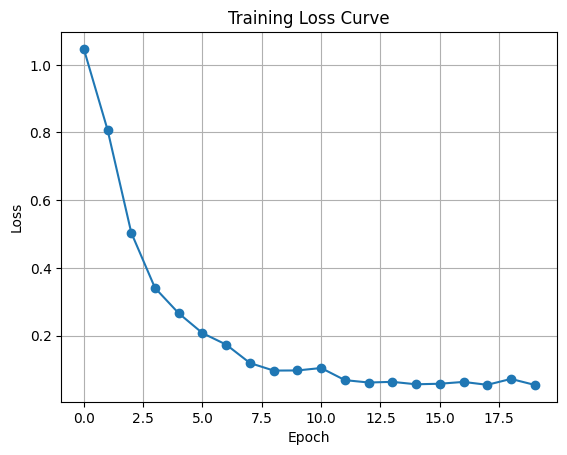

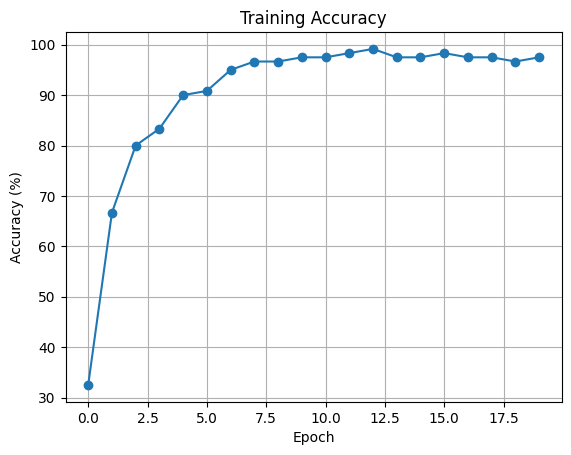

In [28]:
# Loss Curve
plt.figure()
plt.plot(train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Accuracy Curve
plt.figure()
plt.plot(train_acc, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

## 12. Evaluate Model on Test Data

In [29]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 100.00%


## 13. Generate and Display Confusion Matrix

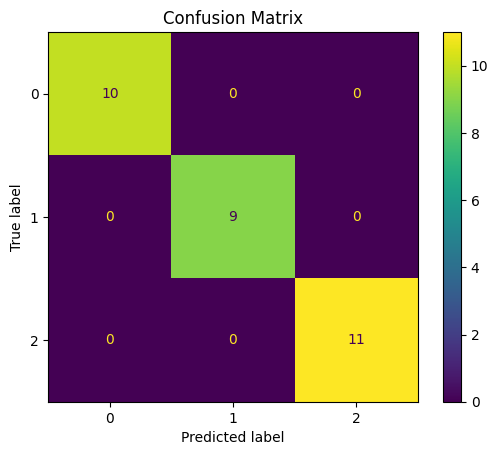

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

## 14. Make Predictions on Sample Data

In [31]:
sample = X_test[:5]
outputs = model(sample)
_, preds = torch.max(outputs, 1)

print("Predictions:", preds.numpy())
print("Actual:", y_test[:5].numpy())

Predictions: [1 0 2 1 1]
Actual: [1 0 2 1 1]
